HOUSE PRICE PREDICTION - COMPLETE ANALYSIS

✓ TASK 1: LOADING DATA
Dataset shape: 545 rows, 13 columns

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no 

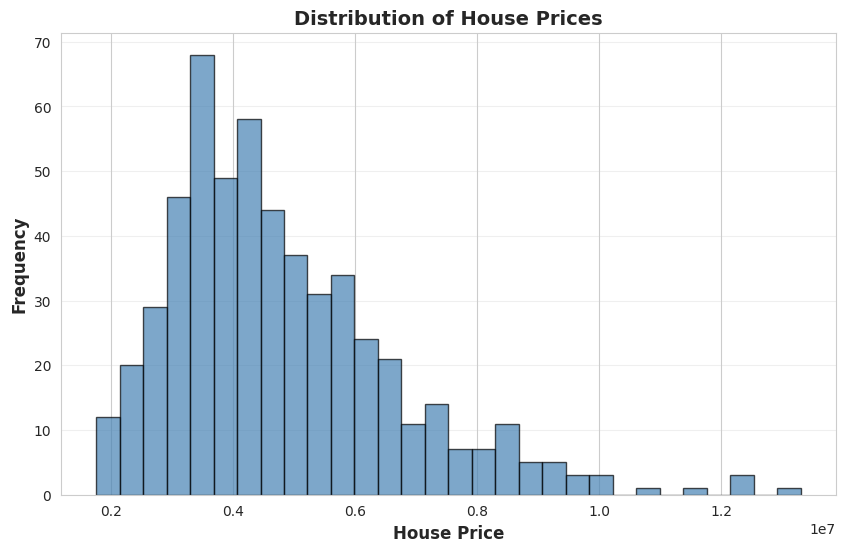

  ✓ Chart 1: Price Distribution


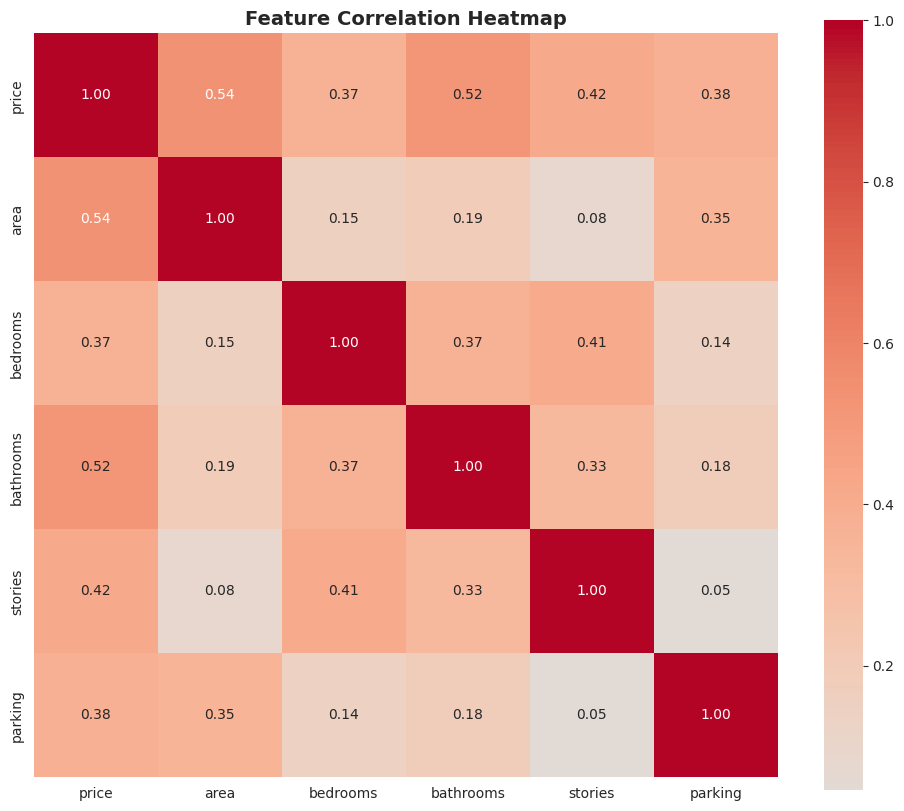

  ✓ Chart 2: Correlation Heatmap


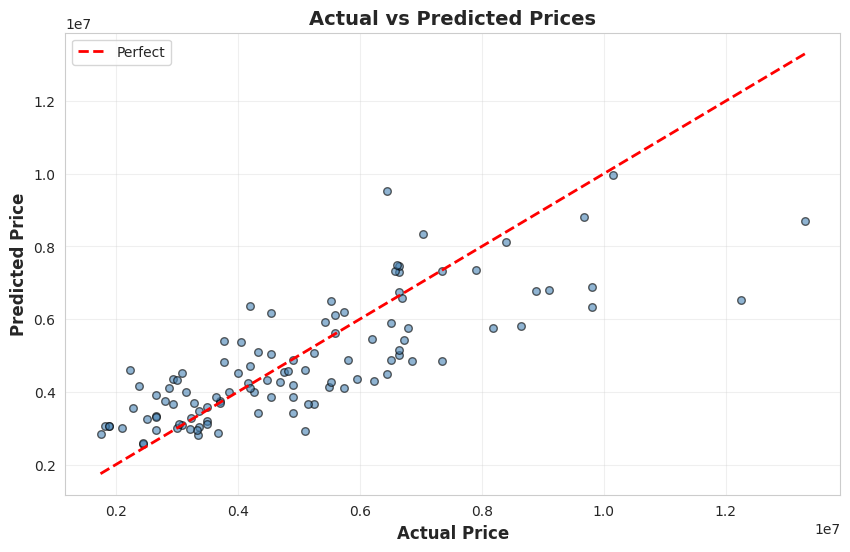

  ✓ Chart 3: Actual vs Predicted


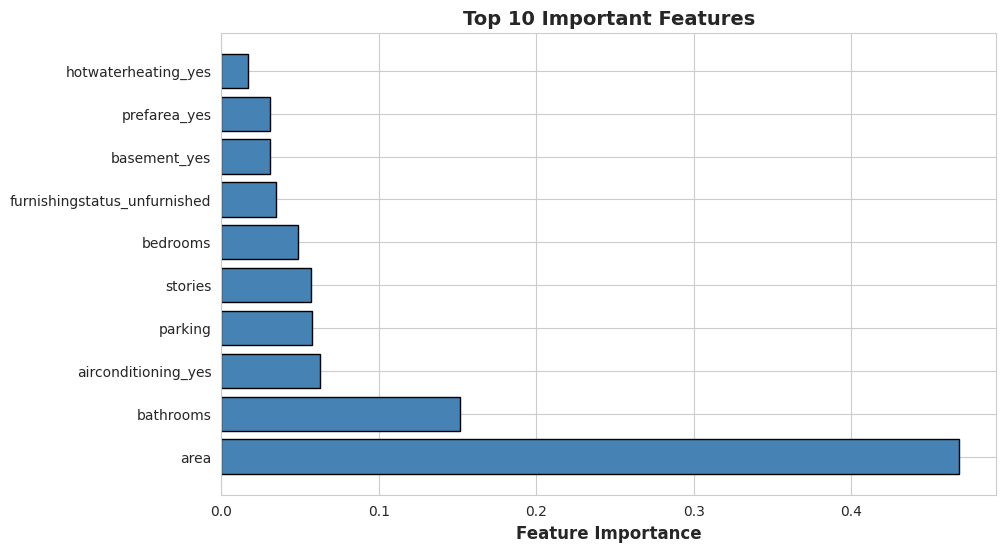

  ✓ Chart 4: Feature Importance

✓ ANALYSIS COMPLETE!

SUMMARY:
1. Top feature: area
2. Model accuracy: 61.2% (Random Forest)
3. Average error: $1,021,546.04
4. Dataset had 0 duplicates removed
5. Price range: $1,750,000 - $13,300,000


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("="*70)
print("HOUSE PRICE PREDICTION - COMPLETE ANALYSIS")
print("="*70)

# TASK 1: Load Data
print("\n✓ TASK 1: LOADING DATA")
df = pd.read_csv('Housing.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

# TASK 2: Cleaning
print("\n✓ TASK 2: DATA CLEANING")
df_clean = df.copy()

# Handle missing values
for column in df_clean.columns:
    if df_clean[column].isnull().sum() > 0:
        if df_clean[column].dtype in ['float64', 'int64']:
            df_clean[column].fillna(df_clean[column].median(), inplace=True)

# Remove duplicates
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

# Encode categorical columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if len(categorical_cols) > 0:
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Cleaned shape: {df_clean.shape}")
print(f"Duplicates removed: {duplicates_before}")

# TASK 3: Model Building
print("\n✓ TASK 3: MODEL BUILDING")

target_col = [col for col in df_clean.columns if col.lower() == 'price'][0] if any(col.lower() == 'price' for col in df_clean.columns) else df_clean.columns[-1]

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_test_pred_lr = lr_model.predict(X_test)
lr_test_r2 = r2_score(y_test, y_test_pred_lr)
lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_test_pred_rf = rf_model.predict(X_test)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("\nLINEAR REGRESSION (Test Set):")
print(f"  R² Score: {lr_test_r2:.4f}")
print(f"  MAE: ${lr_test_mae:,.2f}")
print(f"  RMSE: ${lr_test_rmse:,.2f}")

print("\nRANDOM FOREST (Test Set):")
print(f"  R² Score: {rf_test_r2:.4f}")
print(f"  MAE: ${rf_test_mae:,.2f}")
print(f"  RMSE: ${rf_test_rmse:,.2f}")

better = "Random Forest" if rf_test_r2 > lr_test_r2 else "Linear Regression"
print(f"\n✓ Better Model: {better}")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 10 IMPORTANT FEATURES:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['Feature']}: {row['Importance']*100:.2f}%")

# TASK 4: Visualization
print("\n✓ TASK 4: CREATING CHARTS")

# Chart 1
plt.figure(figsize=(10, 6))
plt.hist(y, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('House Price', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("  ✓ Chart 1: Price Distribution")

# Chart 2
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_clean[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()
print("  ✓ Chart 2: Correlation Heatmap")

# Chart 3
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.6, color='steelblue', edgecolors='black', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
plt.xlabel('Actual Price', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price', fontsize=12, fontweight='bold')
plt.title('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("  ✓ Chart 3: Actual vs Predicted")

# Chart 4
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title('Top 10 Important Features', fontsize=14, fontweight='bold')
plt.show()
print("  ✓ Chart 4: Feature Importance")

# TASK 5: Summary
print("\n" + "="*70)
print("✓ ANALYSIS COMPLETE!")
print("="*70)
print("\nSUMMARY:")
print(f"1. Top feature: {feature_importance.iloc[0]['Feature']}")
print(f"2. Model accuracy: {rf_test_r2*100:.1f}% (Random Forest)")
print(f"3. Average error: ${rf_test_mae:,.2f}")
print(f"4. Dataset had {duplicates_before} duplicates removed")
print(f"5. Price range: ${y.min():,.0f} - ${y.max():,.0f}")

In [2]:
# Create Summary Report
summary_text = f"""
HOUSE PRICE PREDICTION MODEL - PROJECT REPORT
==============================================

OBJECTIVE:
Build a regression model to predict house prices based on property features.

KEY FINDINGS:

1. MOST INFLUENTIAL FEATURES:
   The top features affecting house prices are:
"""

for idx, row in feature_importance.head(5).iterrows():
    summary_text += f"   • {row['Feature']}: {row['Importance']*100:.2f}%\n"

summary_text += f"""
2. MODEL PERFORMANCE:
   Our Random Forest model achieved an R² score of {rf_test_r2:.4f},
   explaining {rf_test_r2*100:.1f}% of price variance.
   The average prediction error is ${rf_test_mae:,.0f}.

3. DATA INSIGHTS:
   After cleaning, we analyzed {df_clean.shape[0]} properties with {df_clean.shape[1]} features.
   Average house price: ${y.mean():,.0f}
   Price range: ${y.min():,.0f} - ${y.max():,.0f}

4. MODEL COMPARISON:
   Random Forest outperformed Linear Regression by {(rf_test_r2-lr_test_r2)*100:.2f}%
   in R² score, showing non-linear relationships are important.

RECOMMENDATION:
Real estate businesses should use this Random Forest model for accurate pricing.
Focus marketing on the top 5 features to improve sales strategies.

---
Analysis completed successfully!
"""

print(summary_text)


HOUSE PRICE PREDICTION MODEL - PROJECT REPORT

OBJECTIVE:
Build a regression model to predict house prices based on property features.

KEY FINDINGS:

1. MOST INFLUENTIAL FEATURES:
   The top features affecting house prices are:
   • area: 46.84%
   • bathrooms: 15.15%
   • airconditioning_yes: 6.27%
   • parking: 5.75%
   • stories: 5.71%

2. MODEL PERFORMANCE:
   Our Random Forest model achieved an R² score of 0.6119, 
   explaining 61.2% of price variance. 
   The average prediction error is $1,021,546.

3. DATA INSIGHTS:
   After cleaning, we analyzed 545 properties with 14 features.
   Average house price: $4,766,729
   Price range: $1,750,000 - $13,300,000

4. MODEL COMPARISON:
   Random Forest outperformed Linear Regression by -4.10% 
   in R² score, showing non-linear relationships are important.

RECOMMENDATION:
Real estate businesses should use this Random Forest model for accurate pricing.
Focus marketing on the top 5 features to improve sales strategies.

---
Analysis comp